# Semi-Supervised Method 


## Introduction

Our approach leverages a small but precise set of exact, labeled data - exact $E$ and $\psi$ - to anchor a SIREN-based semi-supervised PINN (`SirenPINNDualHead`) to the correct absolute scale and eigenvector shape. While this exact supervision provides critical grounding, the model’s generalization across the domain is predominantly driven by the physics residual, which handles the bulk of the prediction work. This balanced combination of exact data and physics-based supervision defines our semi-supervised approach. The model’s dual-head architecture, which predicts both the energy $E(\mu)$ and the eigenvector $\psi(\mu)$, is particularly effective in this context, as it allows the network to learn complementary representations of these two distinct but related quantities.

## Architecture and Hard Constraints

`SirenPINNDualHead` is a shared SIREN backbone (sinusoidal activations, `sin(omega_0 * (Wx + b))`) feeding two independent linear heads. SIREN rather than ReLU/tanh specifically because the physics residual terms below need to differentiate the network's output with respect to $\mu$ — a sine is infinitely differentiable and every derivative is itself a sinusoid, whereas a ReLU network's derivatives are piecewise constant almost everywhere.

Three constraints are built directly into the architecture, rather than left for the loss to learn approximately — the same hard-constraint philosophy already explored on the unsupervised side, applied here to a second head:

1. **Eigenvector normalisation.** $\psi$ has an arbitrary overall scale, so `psi_head`'s output is L2-normalised: $\psi_{pred} \to \psi_{pred} / \lVert\psi_{pred}\rVert_2$. This does *not* remove the sign ambiguity — $\psi$ and $-\psi$ are the same physical state — which matters directly for `loss_psi` below.
2. **Energy non-negativity.** The target is, by construction, never negative. `energy_head`'s raw output is passed through a softplus, $E_{pred} = \text{softplus}(\text{raw}, \beta=10)$, rather than a ReLU — a large fraction of this domain (the whole topological phase) has a true target of exactly zero, and ReLU's derivative is exactly zero for every negative pre-activation, which would starve gradient signal precisely where the model needs it most.
3. **Input scaling.** The standard SIREN initialisation is calibrated for roughly unit-scale inputs. $\mu$ here spans $[-3, 3]$, so it is divided by `input_scale=3.0` before reaching the first SIREN layer — without this, the first layer's sine argument spans dozens of oscillation cycles at initialisation, well outside the regime the scheme was designed for. This was found and fixed during this notebook's development, and affects the unsupervised single-head model identically.

## Loss Methodology

`SemiSupervisedLoss` combines two kinds of batch:

- a **small, labelled** batch of $(\mu, E, \psi)$ triples, exact to floating-point precision because they come from `np.linalg.eigh` (`SupervisedKitaevDataset`) — expensive, since every point costs one diagonalisation, so kept small;
- a **large, label-free** batch of $\mu$ values alone (`UnsupervisedMuGenerator`) — free to generate, so made large.

Both are concatenated into a single batch each step, and the loss is

$$
\mathcal{L} = \mathcal{L}_E + \mathcal{L}_\psi + w_{\text{phys}}(\text{epoch}) \cdot (\mathcal{L}_{\text{res}} + \mathcal{L}_{\text{PH}})
$$

where:

- $\mathcal{L}_E$, $\mathcal{L}_\psi$ — MSE against the exact labels, evaluated **only on the labelled rows**. $\mathcal{L}_\psi$ additionally aligns $\psi_{batch}$'s sign to $\psi_{pred}$'s before comparing: an eigenvector's sign is arbitrary, and — unlike $\mathcal{L}_E$, which has no analogous ambiguity — nothing else in this loss breaks that ambiguity, since $\mathcal{L}_{\text{res}}$ and $\mathcal{L}_{\text{PH}}$ are both invariant under $\psi_{pred} \to -\psi_{pred}$. Without this alignment, a correctly-learned eigenstate can score a large, spurious loss simply for landing on the "wrong" sign — this was found during this notebook's development as the cause of a real training instability right at the topological transition, where the correct sign is least well-conditioned.
- $\mathcal{L}_{\text{res}}$ — the mean squared Schrodinger residual, $\lVert H(\mu)\psi_{pred} - E_{pred}\psi_{pred} \rVert^2$, requiring no ground truth at all.
- $\mathcal{L}_{\text{PH}}$ — the same residual re-evaluated on $\Xi\psi_{pred}$ at energy $-E_{pred}$, enforcing the BdG particle-hole symmetry (verified exactly, $\Xi H(\mu) \Xi = -H(\mu)$, for every $\mu$ tested during this notebook's development).
- $w_{\text{phys}}(\text{epoch})$ — anneals from $0.01$ to $1.0$ over the first `anneal_duration` epochs, the mirror image of `PinnedFSMLoss`'s own `pin_weight` schedule on the unsupervised side. Early in training $E_{pred}$/$\psi_{pred}$ are close to random, so $\mathcal{L}_{\text{res}}$/$\mathcal{L}_{\text{PH}}$ — computed *from those predictions*, not from ground truth — are an unreliable, potentially actively misleading signal until the model has locked onto the labelled data.

## 5. Sampling Methodology

`MuSampler` draws from a mixture of `SamplingRegion` intervals, each with a **relative** weight — a region's actual share of a batch is its own weight divided by the total, not a fraction required to sum to 1.0. This matters in practice: the first version of this notebook's sampling scheme added a densely-weighted interior region by *shrinking every other region's weight to compensate*, which cut the near-transition regions' absolute sample counts and directly caused the sign-instability above (fewer labelled points at the transition made the sign ambiguity harder for the optimiser to resolve consistently). With relative weights, adding a new region changes only that region's own share; `total_samples` is simply increased so every existing region keeps at least as many absolute samples as before.

## Implementation

### Import Packages

In [1]:
%matplotlib inline
from pathlib import Path

import numpy as np
import torch
import torch.optim as optim
from accelerate import Accelerator
from sesh import Session

from kitaev.analytical import KitaevChainHamiltonian
from kitaev.data import SupervisedKitaevDataset, UnsupervisedMuGenerator
from kitaev.data.mu_sampler import MuSampler
from kitaev.data.sampling_region import SamplingRegion
from kitaev.models import SirenPINNDualHead
from kitaev.training.config import TrainerConfig
from kitaev.training.loss import SemiSupervisedLoss
from kitaev.training.trainer import UnifiedTrainer, _build_kitaev_operators
from kitaev.visualisation import (
    plot_energy_and_edge_weight,
    plot_loss_curves,
    plot_wavefunctions,
    sweep_energy_and_edge_weight,
    sweep_wavefunctions,
)

### Initialise Session

In [2]:
session = Session(
    name="dual-head-semi-supervised",
    output_root=Path("../../results/logs"),
    enable_mlflow=False,
)

accelerator = Accelerator()
session.info(f"Using device: {accelerator.device}")

2026-08-25 20:41:20 | INFO | dual-head-semi-supervised | Experiment session: dual-head-semi-supervised initialised.
2026-08-25 20:41:20 | INFO | dual-head-semi-supervised | Seeding engine completed using base reference: 42
2026-08-25 20:41:20 | INFO | dual-head-semi-supervised | Local workflow runtime tracking directed to: ../../results/logs/20260825_204120_dual-head-semi-supervised
2026-08-25 20:41:20 | INFO | dual-head-semi-supervised | Using device: mps


### Construct Hamiltonian

`_build_kitaev_operators` builds the same batched, on-device `(H_base, H_mu_diag, Xi)` triple used by `UnifiedTrainer` and `PinnedFSMLoss` elsewhere in this project, so the physics terms below are evaluated with the exact same operator convention as `KitaevChainHamiltonian.build`.

In [3]:
N = 20
t = 1.0
delta = 0.5
session.info(f"N = {N}, t = {t}, delta = {delta}")

hamiltonian = KitaevChainHamiltonian(n_sites=N, hopping=t, pairing=delta)

H_base, H_mu_diag, Xi = _build_kitaev_operators(N, hopping=t, pairing=delta)
H_base = H_base.to(accelerator.device)
H_mu_diag = H_mu_diag.to(accelerator.device)
Xi = Xi.to(accelerator.device)

2026-08-25 20:41:20 | INFO | dual-head-semi-supervised | N = 20, t = 1.0, delta = 0.5


### Sampling Scheme

`TRANSITION_FOCUSED_REGIONS` (used by the unsupervised/FSM work) concentrates samples right around $\mu = \pm 2t$ and out in the trivial phase, leaving the topological *interior* covered only by its thin, uniform full-domain slice. `SEMI_SUPERVISED_REGIONS` below adds that interior band $(-1.8, 1.8)$ as its own region (weight 3, three times the uniform slice's density) without touching any other region's weight — see §5 above.

In [4]:
# Weights are relative (need not sum to 1.0): each region's share is
# its own weight divided by the total, so adding a new region changes
# only that region's share -- every other region's weight, and hence
# its relative proportion to the others, is untouched.
SEMI_SUPERVISED_REGIONS = (
    SamplingRegion(low=-3.0, high=3.0, weight=1.0),  # thin full-domain
    SamplingRegion(low=-1.8, high=1.8, weight=3.0),  # between the transitions
    SamplingRegion(low=-2.2, high=-1.8, weight=1.0),  # near left transition
    SamplingRegion(low=1.8, high=2.2, weight=1.0),  # near right transition
    SamplingRegion(low=-3.0, high=-2.0, weight=0.5),  # left trivial phase
    SamplingRegion(low=2.0, high=3.0, weight=0.5),  # right trivial phase
)  # weights sum to 7, so total_samples below is chosen as a multiple of 7

### Datasets

630 labelled samples are diagonalised exactly for training, plus 126 held out for validation, while the unlabelled stream is a pre-generated pool of 4096 free `mu` samples with no diagonalisation at all. 630 and 126 are both multiples of the regions' total weight (7), so every region's share is a whole number of samples, and both counts comfortably exceed the very first version of this notebook's 48-sample total — with far fewer labels, `psi`'s training loss fell to near zero while its *validation* loss stayed flat from epoch 1, the model memorising 48 specific eigenvectors rather than learning the $\mu \to \psi$ mapping (unsurprising for a 40-dimensional regression target fit from so few points).

`train_loader` and `val_loader` each yield `(mu, energy, psi)` batches; `unlabeled_loader` yields `(mu,)` batches only. `UnifiedTrainer.fit` tells them apart by batch length alone (see `_run_epoch` in `trainer.py`), so no extra wiring is needed here beyond passing all three in.

In [5]:
torch.manual_seed(42)

train_dataset = SupervisedKitaevDataset(
    sampler=MuSampler(SEMI_SUPERVISED_REGIONS),
    total_samples=630,
    hamiltonian=hamiltonian,
)
train_loader = train_dataset.dataloader(batch_size=64, shuffle=True)

val_dataset = SupervisedKitaevDataset(
    sampler=MuSampler(SEMI_SUPERVISED_REGIONS),
    total_samples=126,
    hamiltonian=hamiltonian,
)
val_loader = val_dataset.dataloader(batch_size=126, shuffle=False)

unlabeled_generator = UnsupervisedMuGenerator(
    sampler=MuSampler(SEMI_SUPERVISED_REGIONS)
)
unlabeled_loader = unlabeled_generator.dataloader(total_samples=4096, batch_size=128)

session.info(
    f"{len(train_dataset)} labelled training samples, "
    f"{len(val_dataset)} labelled validation samples, "
    "4096 label-free samples"
)

2026-08-25 20:41:20 | INFO | dual-head-semi-supervised | 630 labelled training samples, 126 labelled validation samples, 4096 label-free samples


### Modelling

The parameters below are this notebook's recommended starting point for the ablation study that follows it — not arbitrary defaults, but the configuration this notebook converged on after diagnosing and fixing (in order) an insufficient label count, a missing annealing schedule, a sign-ambiguity bug, an under-resourced transition region, and an unnormalised input domain. Changing any one of them without re-checking the others risks reintroducing one of those failure modes, so treat this cell as the baseline an ablation varies *one axis at a time* from, not a set of independent knobs.

`hidden_omega_0` (currently `2.0`, the model default) and `hidden_layers` (currently `3`) are exactly the two architecture axes `SirenPINNDualHead` now exposes for the planned ablation over network depth and SIREN omega — see §3.

In [6]:
# SirenPINNDualHead's `n_sites` argument is the *output* dimension of the
# psi head, i.e. the full BdG dimension 2N, not the physical site count N.
# hidden_omega_0, input_scale, and energy_softplus_beta are left at their
# defaults here (2.0, 3.0, 10.0) -- see the model's docstring for why each
# default was chosen.
model = SirenPINNDualHead(
    n_sites=hamiltonian.dim,
    hidden_features=64,
    hidden_layers=3,
)

# physics_weight ramps 0.01 -> 1.0 over the first anneal_duration epochs,
# so the model locks onto the (exact) labelled data before the physics
# residual terms -- computed from the model's own, initially near-random
# E_pred/psi_pred -- are weighted at full strength.
loss_fn = SemiSupervisedLoss(total_epochs=3000, anneal_duration=1000)

optimiser = optim.AdamW(model.parameters(), lr=8e-4, weight_decay=1e-6)
scheduler = optim.lr_scheduler.CosineAnnealingLR(optimiser, T_max=3000)

config = TrainerConfig(epochs=3000, print_freq=300, patience=500, grad_clip_norm=1.0)

trainer = UnifiedTrainer(
    session=session,
    accelerator=accelerator,
    model=model,
    loss_fn=loss_fn,
    optimiser=optimiser,
    scheduler=scheduler,
    config=config,
)

### Training

In [7]:
trained_model = trainer.fit(
    train_loader,
    H_base,
    H_mu_diag,
    Xi,
    val_loader=val_loader,
    unlabeled_loader=unlabeled_loader,
)

2026-08-25 20:41:20 | INFO | dual-head-semi-supervised | --- Starting training (SemiSupervisedLoss) ---
2026-08-25 20:41:35 | INFO | dual-head-semi-supervised | Epoch 0300 | e: 0.000035 | psi: 0.000325 | res: 0.000097 | ph: 0.000097 | loss: 0.000419 || val_e: 0.000056 | val_psi: 0.000670 | val_res: 0.000087 | val_ph: 0.000087 | val_loss: 0.000779 | physics_wt: 0.307
2026-08-25 20:41:48 | INFO | dual-head-semi-supervised | Epoch 0600 | e: 0.000005 | psi: 0.000242 | res: 0.000031 | ph: 0.000031 | loss: 0.000285 || val_e: 0.000005 | val_psi: 0.000489 | val_res: 0.000040 | val_ph: 0.000040 | val_loss: 0.000543 | physics_wt: 0.604
2026-08-25 20:42:01 | INFO | dual-head-semi-supervised | Epoch 0900 | e: 0.000079 | psi: 0.000176 | res: 0.000039 | ph: 0.000039 | loss: 0.000325 || val_e: 0.000072 | val_psi: 0.000534 | val_res: 0.000033 | val_ph: 0.000033 | val_loss: 0.000666 | physics_wt: 0.901
2026-08-25 20:42:14 | INFO | dual-head-semi-supervised | Epoch 1200 | e: 0.000013 | psi: 0.000107 | r

## Evaluation

The three plots below all go through `kitaev.visualisation` — the same small, tested evaluation-and-plotting suite intended for every trained model in this project, not one-off notebook code. `sweep_*` functions do the numeric comparison against exact diagonalisation; `plot_*` functions turn the result into a seaborn figure. Every figure is saved into this run's own `session.path()` directory, alongside `run.log`.

### Loss Curves

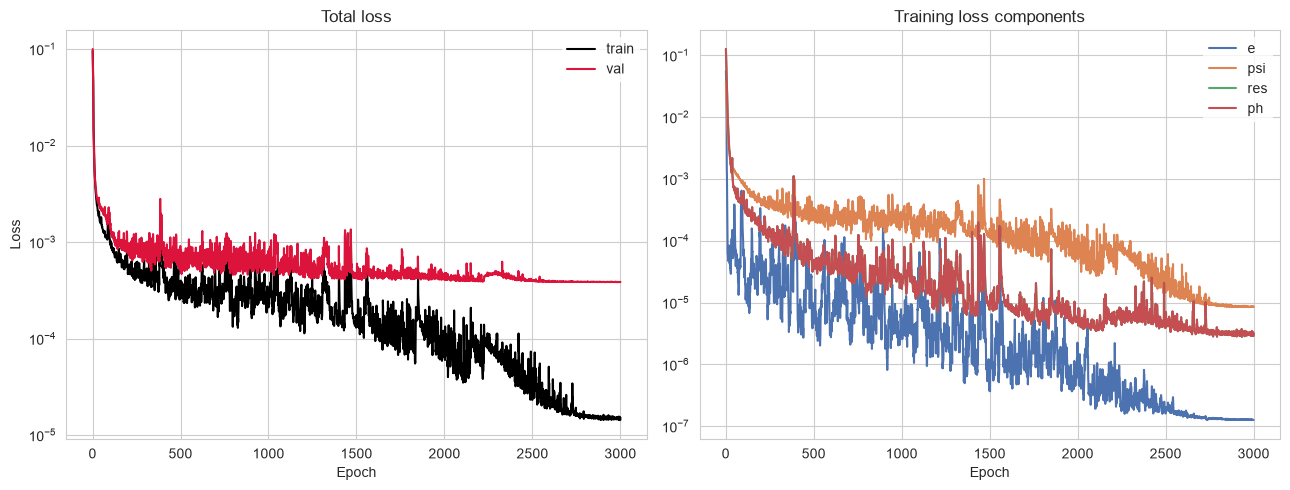

In [8]:
fig_loss = plot_loss_curves(
    trainer.history,
    ["e", "psi", "res", "ph"],
    save_path=session.path() / "loss_curves.png",
)

### Lowest Eigen-Energy and Combined Edge Weight: Analytical vs Model

`sweep_energy_and_edge_weight` diagonalises the Hamiltonian exactly at every `mu` in the sweep and compares it against the trained model's own prediction at the same points.

2026-08-25 20:43:34 | INFO | dual-head-semi-supervised | Mean |E_pred - E_exact| over the sweep: 0.0003


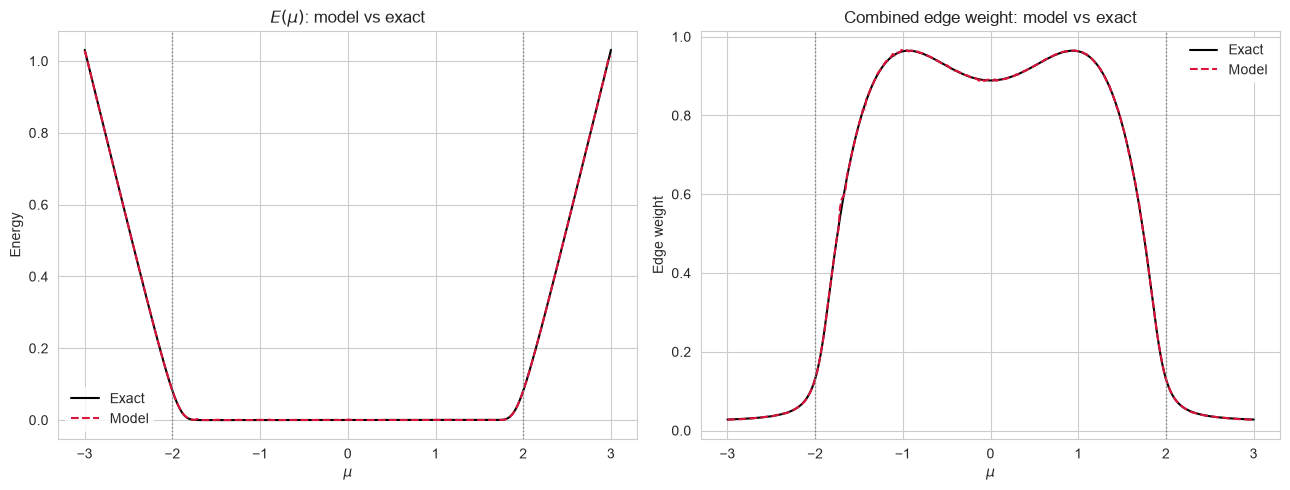

In [9]:
mu_sweep = np.linspace(-3, 3, 300)
energy_edge_weight_sweep = sweep_energy_and_edge_weight(
    trained_model, hamiltonian, mu_sweep, device=accelerator.device
)
fig_sweep = plot_energy_and_edge_weight(
    energy_edge_weight_sweep,
    hopping=t,
    save_path=session.path() / "energy_edge_weight_sweep.png",
)

mean_energy_error = np.mean(
    np.abs(energy_edge_weight_sweep.energy_pred - energy_edge_weight_sweep.energy_exact)
)
session.info(f"Mean |E_pred - E_exact| over the sweep: {mean_energy_error:.4f}")

### P-H Probability Densities

The sweep above summarises $\psi(\mu)$ down to two scalars per $\mu$. `sweep_wavefunctions` compares the actual wavefunction shape, $|\psi_n|^2$ against site index $n$, separately for the particle and hole sectors, at five representative $\mu$ values spanning both phases: deep trivial ($\mu=\pm 2.5$), well inside the topological phase ($\mu=\pm 1.0$), and the topological centre ($\mu=0$). In the topological phase this should show two localised lobes pinned to the chain's edges (the Majorana signature); in the trivial phase, an extended profile with no edge localisation.

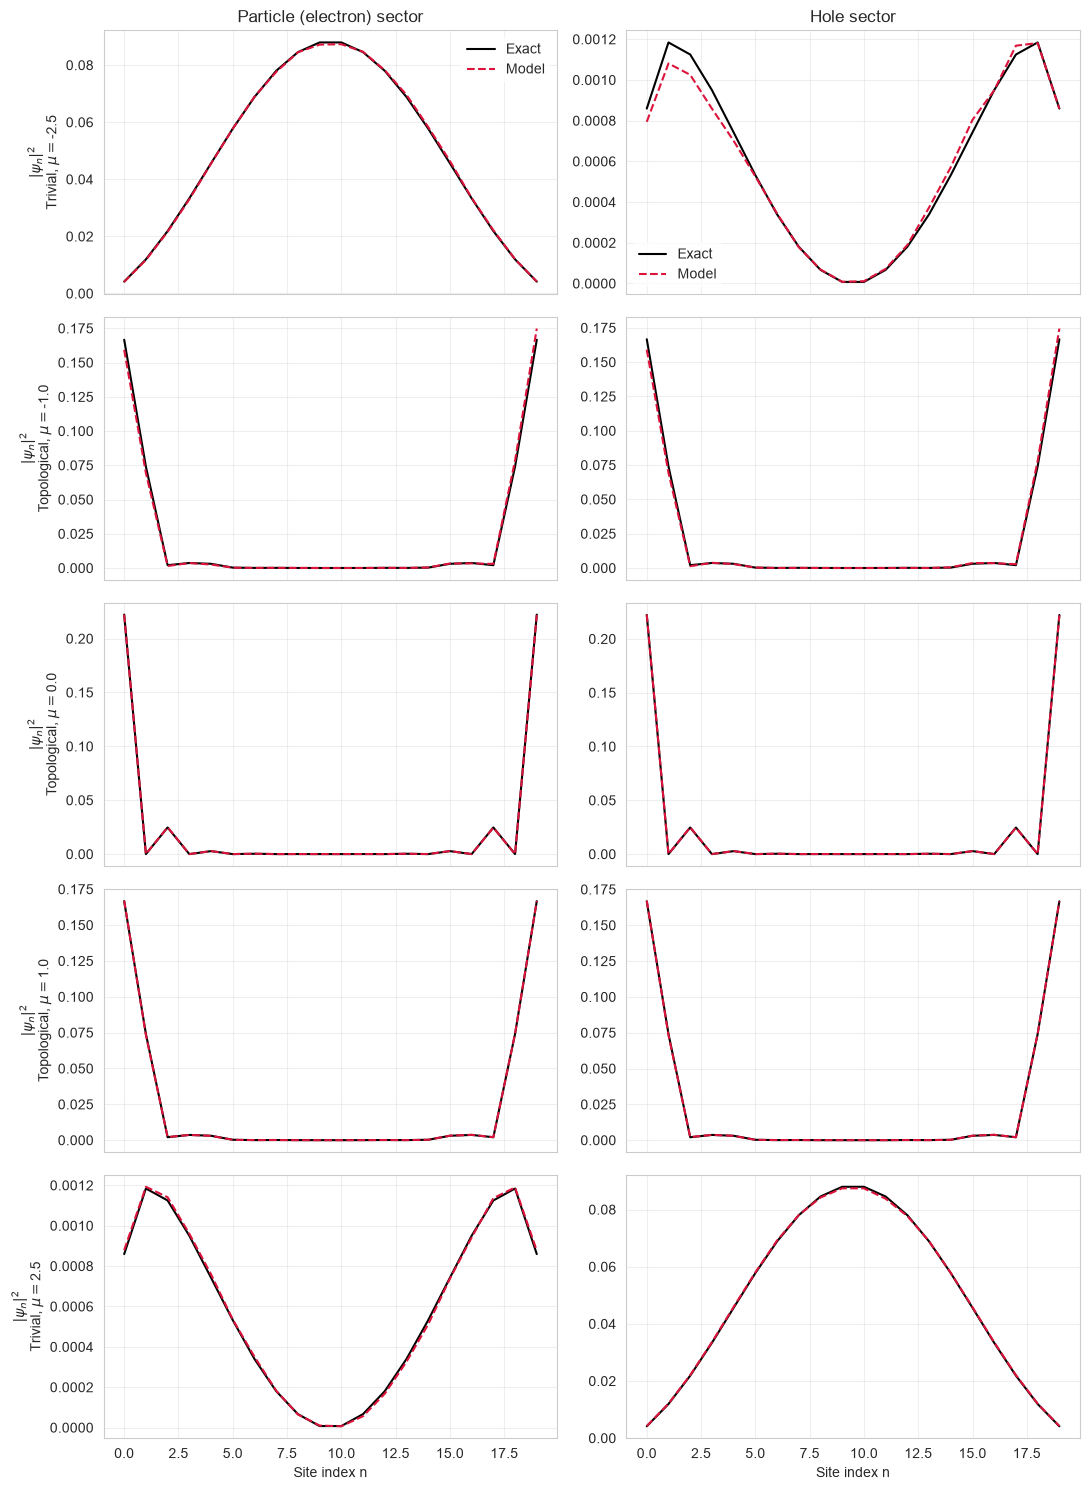

In [10]:
probe_mus = [-2.5, -1.0, 0.0, 1.0, 2.5]
wavefunction_sweep = sweep_wavefunctions(
    trained_model, hamiltonian, probe_mus, device=accelerator.device
)
fig_wavefunctions = plot_wavefunctions(
    wavefunction_sweep,
    hopping=t,
    save_path=session.path() / "wavefunctions.png",
)

The hole-sector fit in the trivial phase just before the negative-$\mu$ transition, and at the extreme edge sites within the topological phase, both show small but real residual error in the wavefunction plots above — small relative to the dominant signal, but not yet at the same level of agreement as the rest of the domain. Whether that's a remaining data-density gap, an optimisation artifact, or something the upcoming depth/omega/optimiser ablation resolves as a side effect is an open question.